In [ ]:
# run this first cell in Colab
!pip install openpyxl --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# sklearn imports
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor


In [3]:
import pandas as pd

# If using Colab file upload:
from google.colab import files
# files.upload()   # uncomment to upload interactively

# If using Drive:
# from google.colab import drive
# drive.mount('/content/drive')

# Replace with the correct file paths if different
hospital_path = "/content/Hospitalisation details.csv"
medical_path = "/content/Medical Examinations.csv"
names_path = "/content/Names.xlsx"

df_hosp = pd.read_csv(hospital_path)
df_med = pd.read_csv(medical_path)
df_names = pd.read_excel(names_path, engine='openpyxl')

print("Hospital shape:", df_hosp.shape)
print("Medical shape:", df_med.shape)
print("Names shape:", df_names.shape)

# Quick peek
display(df_hosp.head())
display(df_med.head())
display(df_names.head())

Hospital shape: (2343, 9)
Medical shape: (2335, 8)
Names shape: (2335, 2)


,Customer ID,year,month,date,children,charges,Hospital tier,City tier,State ID
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,R1013
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,R1013
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,R1013
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,R1013
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,R1013


,Customer ID,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker
0,Id1,47.410,7.47,No,No,No,No major surgery,yes
1,Id2,30.360,5.77,No,No,No,No major surgery,yes
2,Id3,34.485,11.87,yes,No,No,2,yes
3,Id4,38.095,6.05,No,No,No,No major surgery,yes
4,Id5,35.530,5.45,No,No,No,No major surgery,yes


,Customer ID,name
0,Id1,"Hawks, Ms. Kelly"
1,Id2,"Lehner, Mr. Matthew D"
2,Id3,"Lu, Mr. Phil"
3,Id4,"Osborne, Ms. Kelsey"
4,Id5,"Kadala, Ms. Kristyn"


In [4]:
def show_info(df, name):
    print(f"== {name} ==")
    display(df.info())
    display(df.describe(include='all').T)
    print("\nMissing values:\n", df.isna().sum())

show_info(df_hosp, "Hospital")
show_info(df_med, "Medical")
show_info(df_names, "Names")


== Hospital ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2343 entries, 0 to 2342
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer ID    2343 non-null   object 
 1   year           2343 non-null   object 
 2   month          2343 non-null   object 
 3   date           2343 non-null   int64  
 4   children       2343 non-null   int64  
 5   charges        2343 non-null   float64
 6   Hospital tier  2343 non-null   object 
 7   City tier      2343 non-null   object 
 8   State ID       2343 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 164.9+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,2343,2338,?,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2343,48,2004,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,2343,8,Sep,369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,2343.0,NaN,NaN,NaN,15.554844,8.721194,1.0,8.0,15.0,23.0,30.0
children,2343.0,NaN,NaN,NaN,1.026035,1.233847,0.0,0.0,0.0,2.0,5.0
charges,2343.0,NaN,NaN,NaN,13559.06787,11922.658415,563.84,5084.01,9634.54,17029.675,63770.43
Hospital tier,2343,4,tier - 2,1339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City tier,2343,4,tier - 2,812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State ID,2343,17,R1013,614,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:
 Customer ID      0
year             0
month            0
date             0
children         0
charges          0
Hospital tier    0
City tier        0
State ID         0
dtype: int64
== Medical ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2335 entries, 0 to 2334
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             2335 non-null   object 
 1   BMI                     2335 non-null   float64
 2   HBA1C                   2335 non-null   float64
 3   Heart Issues            2335 non-null   object 
 4   Any Transplants         2335 non-null   object 
 5   Cancer history          2335 non-null   object 
 6   NumberOfMajorSurgeries  2335 non-null   object 
 7   smoker                  2335 non-null   object 
dtypes: float64(2), object(6)
memory usage: 146.1+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,2335,2335,Id2335,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,2335.0,NaN,NaN,NaN,30.972649,8.742095,15.01,24.6,30.4,36.3,55.05
HBA1C,2335.0,NaN,NaN,NaN,6.578998,2.228731,4.0,4.9,5.81,7.955,12.0
Heart Issues,2335,2,No,1409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Any Transplants,2335,2,No,2191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancer history,2335,2,No,1944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfMajorSurgeries,2335,4,No major surgery,1074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,2335,3,No,1845,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:
 Customer ID               0
BMI                       0
HBA1C                     0
Heart Issues              0
Any Transplants           0
Cancer history            0
NumberOfMajorSurgeries    0
smoker                    0
dtype: int64
== Names ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2335 entries, 0 to 2334
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer ID  2335 non-null   object
 1   name         2335 non-null   object
dtypes: object(2)
memory usage: 36.6+ KB


None

,count,unique,top,freq
Customer ID,2335,2335,Id2335,1
name,2335,2335,"German, Mr. Aaron K",1



Missing values:
 Customer ID    0
name           0
dtype: int64


In [6]:
import numpy as np

def replace_trivial(df):
    # Common placeholders — expand list if you find more in your data
    trivial = ['?', 'NA', 'N/A', 'na', '--', '', 'None']
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.strip().replace(trivial, np.nan)
    return df

df_hosp = replace_trivial(df_hosp)
df_med  = replace_trivial(df_med)
df_names = replace_trivial(df_names)

# After replacement, show missing percentage
for name, df in [("Hospital", df_hosp), ("Medical", df_med), ("Names", df_names)]:
    pct_missing = (df.isna().sum()/len(df))*100
    print(name, "columns with missing% > 0:")
    display(pct_missing[pct_missing>0].sort_values(ascending=False))

Hospital columns with missing% > 0:


,0
Customer ID,0.256082
month,0.128041
year,0.085361
State ID,0.085361
Hospital tier,0.042680
City tier,0.042680


Medical columns with missing% > 0:


,0
smoker,0.085653


Names columns with missing% > 0:


,0


In [38]:
# Clean NumberOfMajorSurgeries - try to coerce to numeric
def clean_num_surgeries(x):
    if pd.isna(x): return np.nan
    try:
        return int(float(x))
    except:
        # try to parse words for small numbers
        txt = str(x).lower().strip()
        words_to_num = {'zero':0,'one':1,'two':2,'three':3,'four':4,'five':5}
        return words_to_num.get(txt, np.nan)

if 'NumberOfMajorSurgeries' in df_med.columns:
    df_med['NumberOfMajorSurgeries'] = df_med['NumberOfMajorSurgeries'].apply(clean_num_surgeries)

# Convert BMI & HBA1C to numeric
for col in ['BMI','HBA1C']:
    if col in df_med.columns:
        df_med[col] = pd.to_numeric(df[col], errors='coerce')

# Build DOB and Age from year, month, date (Hospital table)
# Some datasets may have day/month/year as separate columns
if set(['year','month','date']).issubset(df_hosp.columns):
    print("\n--- Debugging DOB/Age Calculation ---")
    print("Initial NaNs in year, month, date (df_hosp):")
    print(df_hosp[['year', 'month', 'date']].isna().sum())

    # Ensure year, month, date are cleaned as strings before conversion
    df_hosp['year_str'] = df_hosp['year'].astype(str).str.strip()
    df_hosp['month_str'] = df_hosp['month'].astype(str).str.strip().str.lower()
    df_hosp['date_str'] = df_hosp['date'].astype(str).str.strip()

    print("\nmonth_str value_counts:")
    print(df_hosp['month_str'].value_counts(dropna=False).head(10))

    # Manual mapping for months to handle various string formats robustly
    month_mapping = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12,
        'january': 1, 'february': 2, 'march': 3, 'april': 4, 'june': 6,
        'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12
    }
    df_hosp['month_mapped'] = df_hosp['month_str'].map(month_mapping)

    print("\nNaNs after month mapping:", df_hosp['month_mapped'].isna().sum())

    # Fill any remaining NaNs (e.g., if months were already numbers as strings) with numeric parsing
    df_hosp['month_num_parsed'] = pd.to_numeric(df_hosp['month_str'], errors='coerce')
    df_hosp['month'] = df_hosp['month_mapped'].fillna(df_hosp['month_num_parsed'])

    print("NaNs in month column after all parsing attempts:", df_hosp['month'].isna().sum())

    df_hosp['year'] = pd.to_numeric(df_hosp['year_str'], errors='coerce')
    df_hosp['date'] = pd.to_numeric(df_hosp['date_str'], errors='coerce')

    print("NaNs in year and date after numeric conversion:")
    print(df_hosp[['year', 'date']].isna().sum())
    print("\nFinal NaNs in year, month, date before DOB creation:")
    print(df_hosp[['year', 'month', 'date']].isna().sum())

    # build a safe dob (if month/day invalid will be NaT)
    def make_dob(row):
        try:
            # Ensure year, month, and date are valid integers before passing to Timestamp
            if pd.isna(row['year']) or pd.isna(row['month']) or pd.isna(row['date']):
                return pd.NaT
            return pd.Timestamp(year=int(row['year']), month=int(row['month']), day=int(row['date']))
        except Exception as e:
            # Print the row that caused the error for further debugging
            # print(f"Error creating DOB for row: {row[['year', 'month', 'date']].to_dict()}, Error: {e}")
            return pd.NaT

    df_hosp['DOB'] = df_hosp.apply(make_dob, axis=1)
    # Age relative to today
    today = pd.Timestamp.today()
    df_hosp['age'] = df_hosp['DOB'].apply(lambda d: (today.year - d.year - ((today.month, today.day) < (d.month, d.day))) if pd.notna(d) else np.nan)
    # Drop temporary columns
    df_hosp = df_hosp.drop(columns=['month_str', 'month_mapped', 'month_num_parsed', 'year_str', 'date_str'], errors='ignore')

# If DOB exists directly, compute age (this block handles cases where DOB might be loaded directly)
# This block is now less likely to be needed if parsing from year/month/date is successful
if 'DOB' in df_hosp.columns and df_hosp['DOB'].dtype == 'O':
    df_hosp['DOB'] = pd.to_datetime(df_hosp['DOB'], errors='coerce')
    df_hosp['age'] = df_hosp['DOB'].apply(lambda d: (pd.Timestamp.today().year - d.year - ((pd.Timestamp.today().month, pd.Timestamp.today().day) < (d.month, d.day))) if pd.notna(d) else np.nan)

display(df_med[['NumberOfMajorSurgeries','BMI','HBA1C']].head())
display(df_hosp[['DOB','age']].head())


--- Debugging DOB/Age Calculation ---
Initial NaNs in year, month, date (df_hosp):
year        2
month    2343
date        0
dtype: int64

month_str value_counts:
month_str
nan    2343
Name: count, dtype: int64

NaNs after month mapping: 2343
NaNs in month column after all parsing attempts: 2343
NaNs in year and date after numeric conversion:
year    2
date    0
dtype: int64

Final NaNs in year, month, date before DOB creation:
year        2
month    2343
date        0
dtype: int64


,NumberOfMajorSurgeries,BMI,HBA1C
0,NaN,17.58,4.51
1,NaN,17.60,4.39
2,2.0,16.47,6.35
3,NaN,17.70,6.28
4,NaN,22.34,5.57


,DOB,age
0,NaT,NaN
1,NaT,NaN
2,NaT,NaN
3,NaT,NaN
4,NaT,NaN


In [8]:
import re

def extract_gender(name):
    if pd.isna(name): return np.nan
    s = str(name).strip()
    # regex for common salutations at start
    m = re.match(r'^(mr\.?|master|dr\.?|mrs\.?|miss|ms\.?)\s+', s.lower())
    if m:
        tok = m.group(1)
        if tok.startswith('mr') or tok.startswith('master'):
            return 'Male'
        if tok.startswith('mrs') or tok.startswith('miss') or tok.startswith('ms'):
            return 'Female'
        # Dr is unknown -> keep as unknown (could be either)
        if tok.startswith('dr'):
            return 'Unknown'
    # fallback: try to guess by common female names? (NOT recommended)
    return 'Unknown'

# merge name into main via Customer ID later; but add gender in names dataframe
if 'name' in df_names.columns:
    df_names['gender'] = df_names['name'].apply(extract_gender)
    df_names[['name','gender']].head(10)


In [9]:
# normalize column names
def norm_cols(df):
    df.columns = [c.strip() for c in df.columns]
    return df

df_hosp = norm_cols(df_hosp)
df_med = norm_cols(df_med)
df_names = norm_cols(df_names)

# Common key name
key = 'Customer ID'
for df,name in [(df_hosp,'hosp'),(df_med,'med'),(df_names,'names')]:
    if key not in df.columns:
        print(f"Warning: {key} not in {name} columns. Found: {df.columns.tolist()}")

# Merge all
df = df_hosp.merge(df_med, on=key, how='left').merge(df_names, on=key, how='left')
print("Merged shape:", df.shape)
display(df.head())


Merged shape: (2343, 20)


,Customer ID,year,month,date,children,charges,Hospital tier,City tier,State ID,DOB,age,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,name,gender
0,Id2335,1992.0,NaN,9,0,563.84,tier - 2,tier - 3,R1013,NaT,NaN,17.58,4.51,No,No,No,1.0,No,"German, Mr. Aaron K",Unknown
1,Id2334,1992.0,NaN,30,0,570.62,tier - 2,tier - 1,R1013,NaT,NaN,17.60,4.39,No,No,No,1.0,No,"Rosendahl, Mr. Evan P",Unknown
2,Id2333,1993.0,NaN,30,0,600.00,tier - 2,tier - 1,R1013,NaT,NaN,16.47,6.35,No,No,Yes,1.0,No,"Albano, Ms. Julie",Unknown
3,Id2332,1992.0,NaN,13,0,604.54,tier - 3,tier - 3,R1013,NaT,NaN,17.70,6.28,No,No,No,1.0,No,"Riveros Gonzalez, Mr. Juan D. Sr.",Unknown
4,Id2331,1998.0,NaN,27,0,637.26,tier - 3,tier - 3,R1013,NaT,NaN,22.34,5.57,No,No,No,1.0,No,"Brietzke, Mr. Jordan",Unknown


In [10]:
# percent of rows with any trivial/missing fields
pct_rows_with_any_na = (df.isna().any(axis=1).sum()/len(df))*100
print(f"Percent of rows with any missing fields: {pct_rows_with_any_na:.2f}%")

# percent rows with all NaN except key maybe
pct_allnan = (df.drop(columns=[key]).isna().all(axis=1).sum()/len(df))*100
print(f"Percent of rows with all-other NaN: {pct_allnan:.2f}%")

# duplicates on key
dups = df.duplicated(subset=[key]).sum()
print("Duplicate Customer ID rows:", dups)


Percent of rows with any missing fields: 100.00%
Percent of rows with all-other NaN: 0.00%
Duplicate Customer ID rows: 5


In [11]:
# drop rows that are almost empty (customize threshold)
thresh = int(0.5 * df.shape[1])  # require at least half columns present
df = df.dropna(thresh=thresh).copy()
print("After dropping mostly-empty rows:", df.shape)


After dropping mostly-empty rows: (2335, 20)


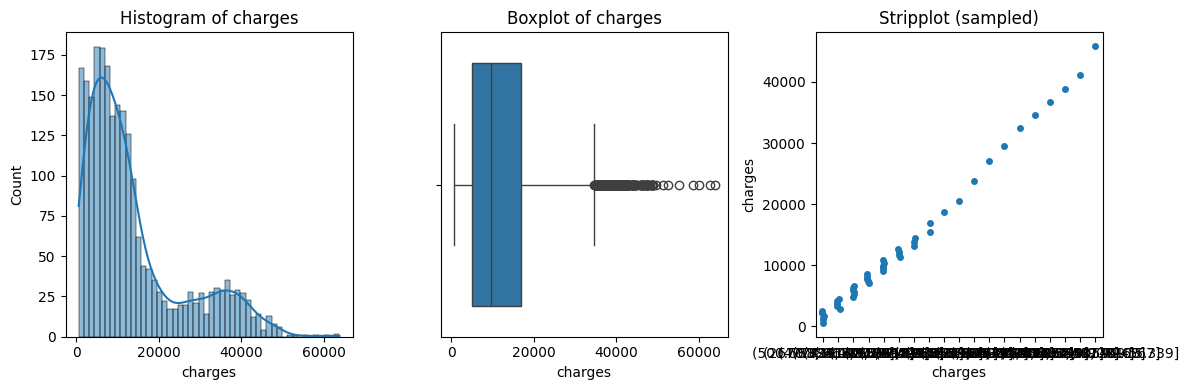

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# ensure charges numeric
df['charges'] = pd.to_numeric(df['charges'], errors='coerce')
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['charges'].dropna(), bins=50, kde=True)
plt.title('Histogram of charges')

plt.subplot(1,3,2)
sns.boxplot(x=df['charges'])
plt.title('Boxplot of charges')

plt.subplot(1,3,3)
# stripplot for better visualization without overcrowding
sns.stripplot(x=pd.cut(df['charges'], bins=30).astype(str).iloc[::50], y=df['charges'].iloc[::50])
plt.title('Stripplot (sampled)')
plt.tight_layout()

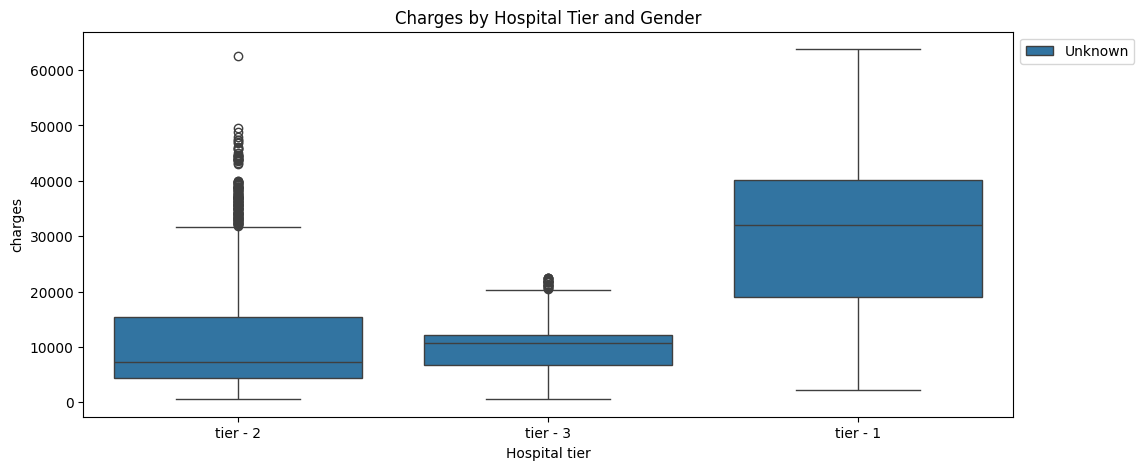

In [15]:
# Ensure hospital tier column exists
if 'Hospital tier' in df.columns:
    plt.figure(figsize=(12,5))
    sns.boxplot(x='Hospital tier', y='charges', hue='gender', data=df)
    plt.title('Charges by Hospital Tier and Gender')
    plt.legend(bbox_to_anchor=(1,1))
else:
    print("No 'Hospital tier' column found. Columns:", df.columns)


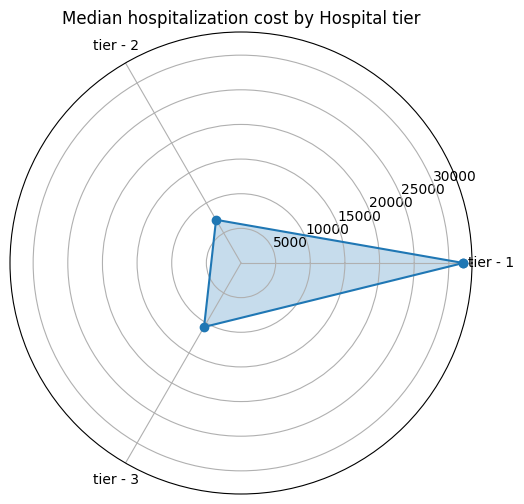

In [16]:
# Radar chart (median cost per Hospital tier)
if 'Hospital tier' in df.columns:
    med = df.groupby('Hospital tier')['charges'].median().dropna()
    labels = med.index.astype(str).tolist()
    values = med.values.tolist()
    # radar requires closed loop
    values += values[:1]
    angles = np.linspace(0, 2*np.pi, len(labels)+1, endpoint=True)
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(angles, values, marker='o')
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(angles[:-1]*180/np.pi, labels)
    ax.set_title('Median hospitalization cost by Hospital tier')
    plt.show()
else:
    print("Missing Hospital tier column")


Hospital tier,tier - 1,tier - 2,tier - 3
City tier,,,
tier - 1,86,404,242
tier - 2,107,479,222
tier - 3,111,454,228


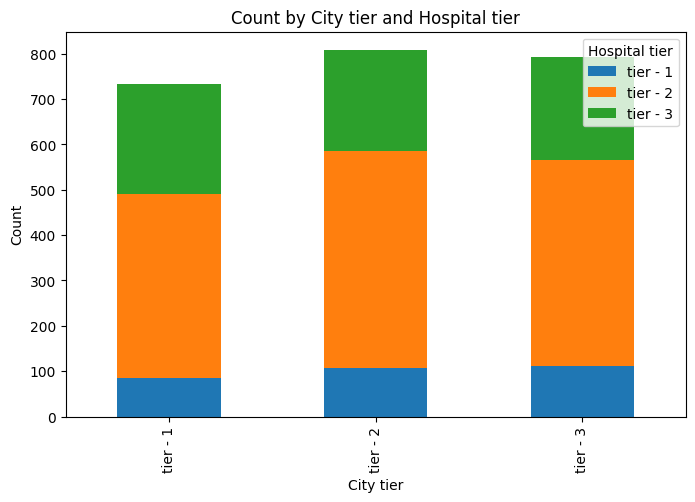

In [17]:
if 'City tier' in df.columns and 'Hospital tier' in df.columns:
    freq = pd.crosstab(df['City tier'], df['Hospital tier'])
    display(freq)
    freq.plot(kind='bar', stacked=True, figsize=(8,5))
    plt.title('Count by City tier and Hospital tier')
    plt.xlabel('City tier')
    plt.ylabel('Count')
    plt.show()


In [18]:
import scipy.stats as stats

# a) ANOVA: average hospitalization costs for the three types of hospitals
if 'Hospital tier' in df.columns:
    groups = [group['charges'].dropna().values for name, group in df.groupby('Hospital tier')]
    fstat, pval = stats.f_oneway(*groups)
    print("ANOVA Hospital tier: F =", fstat, "p =", pval)
else:
    print("Hospital tier missing for ANOVA")

# b) ANOVA: cities
if 'City tier' in df.columns:
    groups = [group['charges'].dropna().values for name, group in df.groupby('City tier')]
    fstat2, pval2 = stats.f_oneway(*groups)
    print("ANOVA City tier: F =", fstat2, "p =", pval2)

# c) t-test: smokers vs nonsmokers
if 'smoker' in df.columns:
    s = df[df['smoker'].astype(str).str.lower().isin(['yes','1','true','y'])]['charges'].dropna()
    ns = df[~df['smoker'].astype(str).str.lower().isin(['yes','1','true','y'])]['charges'].dropna()
    tstat, ptt = stats.ttest_ind(s, ns, equal_var=False, nan_policy='omit')
    print("t-test smoker vs nonsmoker: t =", tstat, "p =", ptt)

# d) Chi-square: smoking and heart issues independence
if 'smoker' in df.columns and 'Heart Issues' in df.columns:
    ct = pd.crosstab(df['smoker'].fillna('NA'), df['Heart Issues'].fillna('NA'))
    chi2, p, dof, ex = stats.chi2_contingency(ct)
    print("Chi2:", chi2, "p:", p)


ANOVA Hospital tier: F = 498.15763301197507 p = 7.41341024005916e-181
ANOVA City tier: F = 1.385134706258573 p = 0.25049601209361183
t-test smoker vs nonsmoker: t = 56.22258351968991 p = 8.814267987776458e-238
Chi2: 1.3941176869396663 p: 0.4980479888388789


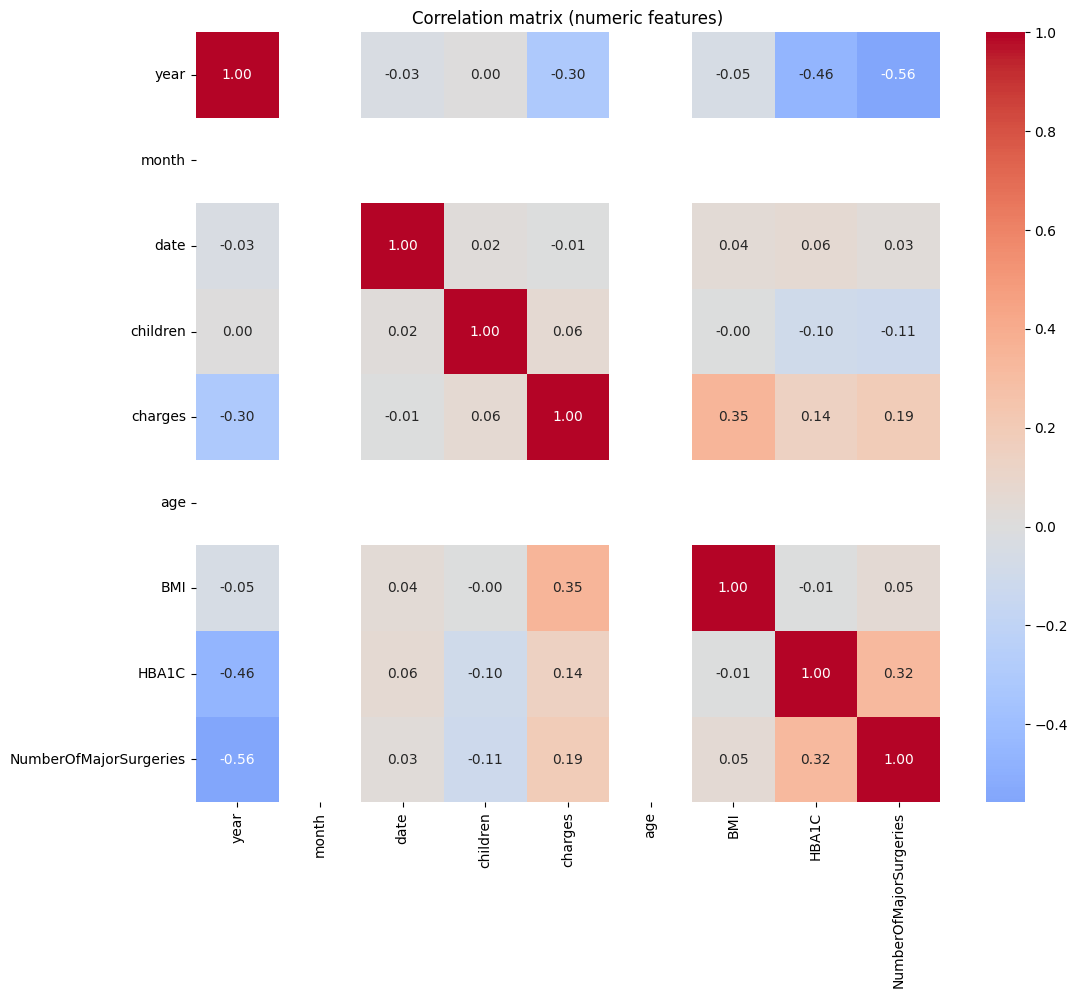

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation matrix (numeric features)')
plt.show()


In [20]:
# State encoding strategy
if 'State ID' in df.columns:
    df['State ID'] = df['State ID'].astype(str)
    key_states = ['R1011','R1012','R1013']
    df['state_group'] = df['State ID'].apply(lambda x: x if x in key_states else 'Other')

# Numeric features
df['is_smoker'] = df['smoker'].astype(str).str.lower().isin(['yes','1','true','y']).astype(int)
df['has_heart_issue'] = df['Heart Issues'].astype(str).str.lower().isin(['yes','1','true','y']).astype(int)
df['is_diabetic'] = pd.to_numeric(df['HBA1C'], errors='coerce').apply(lambda x: 1 if pd.notna(x) and x>6.5 else 0)

# BMI category
def bmi_cat(b):
    try:
        b = float(b)
        if b < 18.5: return 'Underweight'
        if b < 25: return 'Normal'
        if b < 30: return 'Overweight'
        return 'Obese'
    except:
        return np.nan
df['bmi_cat'] = df['BMI'].apply(bmi_cat)

# Keep a working feature list
features = ['age','children','Hospital tier','City tier','state_group','is_smoker','has_heart_issue','is_diabetic','NumberOfMajorSurgeries','bmi_cat']
# ensure these exist
features = [f for f in features if f in df.columns]
print("Model candidate features:", features)


Model candidate features: ['age', 'children', 'Hospital tier', 'City tier', 'state_group', 'is_smoker', 'has_heart_issue', 'is_diabetic', 'NumberOfMajorSurgeries', 'bmi_cat']


In [21]:
df_model = df.copy()
df_model = df_model.dropna(subset=['charges'])  # drop if target missing
y = df_model['charges']

# create strata
df_model['charge_bin'] = pd.qcut(y, q=5, labels=False, duplicates='drop')
print("Charge bins distribution:\n", df_model['charge_bin'].value_counts())

X = df_model[features].copy()

# For simplicity, fill naive missing for train/test split afterwards using pipeline


Charge bins distribution:
 charge_bin
0    467
1    467
2    467
3    467
4    467
Name: count, dtype: int64


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
import numpy as np

# Define a named function for converting to dense array, replacing the lambda
def to_dense(X):
    return X.toarray()

# Define columns types
num_feats = [c for c in X.columns if X[c].dtype in [np.number, 'int64','float64'] and c!='Hospital tier' and c!='City tier']
cat_feats = [c for c in X.columns if c not in num_feats]

# Numeric transformer
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer (OneHot)
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore')),
    ('to_dense', FunctionTransformer(to_dense, accept_sparse=True))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_feats),
    ('cat', cat_transformer, cat_feats)
])

/tmp/ipython-input-4172654941.py:12: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  num_feats = [c for c in X.columns if X[c].dtype in [np.number, 'int64','float64'] and c!='Hospital tier' and c!='City tier']


In [30]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge

# Define the stratified splitter based on the charge_bin
skf_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate the actual train/test splits once using X and the binned target (charge_bin)
# This iterable of (train_index, test_index) will be passed to cv arguments.
stratified_folds = list(skf_splitter.split(X, df_model['charge_bin']))

def run_model(estimator, param_grid, model_name="model"):
    pipe = Pipeline([
        ('preproc', preprocessor),
        ('model', estimator)
    ])
    # Using GridSearch with the pre-generated stratified folds
    gs = GridSearchCV(pipe, param_grid, cv=stratified_folds, scoring='neg_root_mean_squared_error', verbose=1, n_jobs=-1)
    gs.fit(X, y)  # y is the continuous target here for model fitting
    print("Best params for", model_name, ":", gs.best_params_)
    print("Best CV RMSE:", -gs.best_score_)
    return gs

# Linear Regression (no hyperparams really)
lr = LinearRegression()
# Actually perform cross_val for LinearRegression using the stratified folds:
pipe_lr = Pipeline([('preproc', preprocessor), ('model', LinearRegression())])
scores = -cross_val_score(pipe_lr, X, y, cv=stratified_folds, scoring='neg_root_mean_squared_error', n_jobs=-1)
print("LinearRegression CV RMSE:", scores.mean(), "std:", scores.std())

# Ridge with grid
ridge = Ridge()
param_grid_ridge = {'model__alpha':[0.1,1.0,10,50,100]}
gs_ridge = run_model(ridge, param_grid_ridge, "Ridge")

LinearRegression CV RMSE: 5232.207528741888 std: 185.16780025669865
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params for Ridge : {'model__alpha': 10}
Best CV RMSE: 5231.645007532958


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['age']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [41]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

param_grid_gbr = {
    'model__n_estimators':[100,200],
    'model__learning_rate':[0.05,0.1],
    'model__max_depth':[3,5]
}

gs_gbr = run_model(gbr, param_grid_gbr, "GradientBoosting")


Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['age']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best params for GradientBoosting : {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
Best CV RMSE: 4430.290885841816


In [44]:
# Best model (contains preprocessor + model)
best_pipeline = gs_gbr.best_estimator_

preprocessor = best_pipeline.named_steps['preproc']

# Get the original numerical and categorical feature names passed to the preprocessor
# These are `num_feats` and `cat_feats` from the `mgWi8RDcvD2B` cell
# We need to consider that 'age' might have been skipped if it was all NaNs in X

# Filter out numerical features that were all NaNs in the input X (and thus skipped by imputer)
# `num_feats` is available in the kernel state from a previous cell.
# The actual `X` dataframe for this run is also in kernel state.
active_num_features = [col for col in num_feats if not X[col].isnull().all()]

# Get the OneHotEncoder step and its output feature names
ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
ohe_features = ohe.get_feature_names_out(cat_feats)

# Combine the active numerical features with the one-hot encoded categorical features
feature_names = list(active_num_features) + list(ohe_features)

best_gbr = best_pipeline.named_steps['model']
importances = best_gbr.feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
display(fi.head(20))

,0
is_smoker,0.787496
bmi_cat_Obese,0.096157
is_diabetic,0.024786
children,0.017224
Hospital tier_tier - 1,0.016710
NumberOfMajorSurgeries,0.012603
state_group_R1011,0.011833
state_group_R1013,0.005949
has_heart_issue,0.005357
bmi_cat_Underweight,0.004232


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# split into train/test (stratify by charge_bin)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=df_model['charge_bin'], random_state=42)
best = gs_gbr.best_estimator_
best.fit(X_train, y_train)
pred = best.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("Test MAE:", mean_absolute_error(y_test, pred))
print("Test R2:", r2_score(y_test, pred))

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['age']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Test RMSE: 4324.880987575643
Test MAE: 2967.0495024337606
Test R2: 0.868899214921272


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['age']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [49]:
# Build single-row input using the features list we used earlier
patient = {
    # compute age from DOB
    'DOB': pd.Timestamp('1988-12-28'),
    'age': (pd.Timestamp.today().year - 1988 - ((pd.Timestamp.today().month, pd.Timestamp.today().day) < (12,28))),
    'children': 2,
    'Hospital tier':'1',   # tier-1 hospital for cost estimation
    'City tier':'1',       # tier-1 city
    'State ID':'R1011',    # -> mapping to state_group
    'state_group':'R1011',
    'is_smoker':1,
    'has_heart_issue':0,
    'HBA1C':5.8,
    'is_diabetic': 0,
    'NumberOfMajorSurgeries': 0,
    'height_cm':170,
    'weight_kg':85,
    'BMI': 85 / ((170/100)**2),
}

# create DataFrame matching X columns (if column missing fill defaults)
patient_df = pd.DataFrame([patient])
# derive bmi_cat similar to pipeline
patient_df['bmi_cat'] = patient_df['BMI'].apply(bmi_cat)

# make sure columns align
for col in X.columns:
    if col not in patient_df.columns:
        patient_df[col] = np.nan

pred_cost = best.predict(patient_df[X.columns])
print("Predicted hospitalization cost for Ms. Jayna (tier-1 hospital):", float(pred_cost[0]))


Predicted hospitalization cost for Ms. Jayna (tier-1 hospital): 27177.778354048132


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['age']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [51]:
# Create SQLite in-memory DB
import sqlite3
conn = sqlite3.connect('healthcare.db')
df.to_sql('merged', conn, if_exists='replace', index=False)

# Example SQL queries per project tasks:

# 2. Retrieve diabetic + heart problems with average age, avg children, avg BMI, avg charges
query1 = """
SELECT
  AVG(age) as avg_age,
  AVG(children) as avg_children,
  AVG(BMI) as avg_bmi,
  AVG(charges) as avg_charges
FROM merged
WHERE is_diabetic=1 AND has_heart_issue=1
"""
print(pd.read_sql_query(query1, conn))

# 3. Average hospitalization cost for each hospital tier and each city level
q2 = "SELECT [Hospital tier] as hospital_tier, AVG(charges) as avg_charges FROM merged GROUP BY [Hospital tier]"
print(pd.read_sql_query(q2, conn))

q3 = "SELECT [City tier] as city_tier, AVG(charges) as avg_charges FROM merged GROUP BY [City tier]"
print(pd.read_sql_query(q3, conn))

# 4. Number of people who had major surgery with history of cancer
q4 = "SELECT COUNT(*) as count FROM merged WHERE NumberOfMajorSurgeries>0 AND [Cancer history] IS NOT NULL AND [Cancer history]<>''"
print(pd.read_sql_query(q4, conn))

# 5. Number of tier-1 hospitals in each state (assuming dataset has hospital count per state; otherwise approximate by count of records in Hospital tier==1)
q5 = "SELECT [State ID], COUNT(*) as tier1_count FROM merged WHERE [Hospital tier]=1 GROUP BY [State ID]"
print(pd.read_sql_query(q5, conn))

  avg_age  avg_children    avg_bmi   avg_charges
0    None      1.021472  31.337577  16426.542577
  hospital_tier   avg_charges
0          None    700.000000
1      tier - 1  30129.198586
2      tier - 2  11873.619753
3      tier - 3   9462.269307
  city_tier   avg_charges
0      None    770.380000
1  tier - 1  13051.351230
2  tier - 2  13461.221238
3  tier - 3  14057.093665
   count
0   1261
Empty DataFrame
Columns: [State ID, tier1_count]
Index: []


In [55]:
import cloudpickle

best = gs_gbr.best_estimator_
preprocessor = best.named_steps['preproc']

with open("best_model_gbr.pkl", "wb") as f:
    cloudpickle.dump(best, f)

with open("preprocessor.pkl", "wb") as f:
    cloudpickle.dump(preprocessor, f)

print("✅ Model and preprocessor saved successfully")

✅ Model and preprocessor saved successfully


In [56]:
from google.colab import files
files.download('cleaned_data_for_tableau.csv')


FileNotFoundError: Cannot find file: cleaned_data_for_tableau.csv

In [57]:
# Save the cleaned data to a CSV file for Tableau
df.to_csv('cleaned_data_for_tableau.csv', index=False)
print("✅ 'cleaned_data_for_tableau.csv' created successfully")

✅ 'cleaned_data_for_tableau.csv' created successfully


In [58]:
from google.colab import files
files.download('cleaned_data_for_tableau.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>